# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

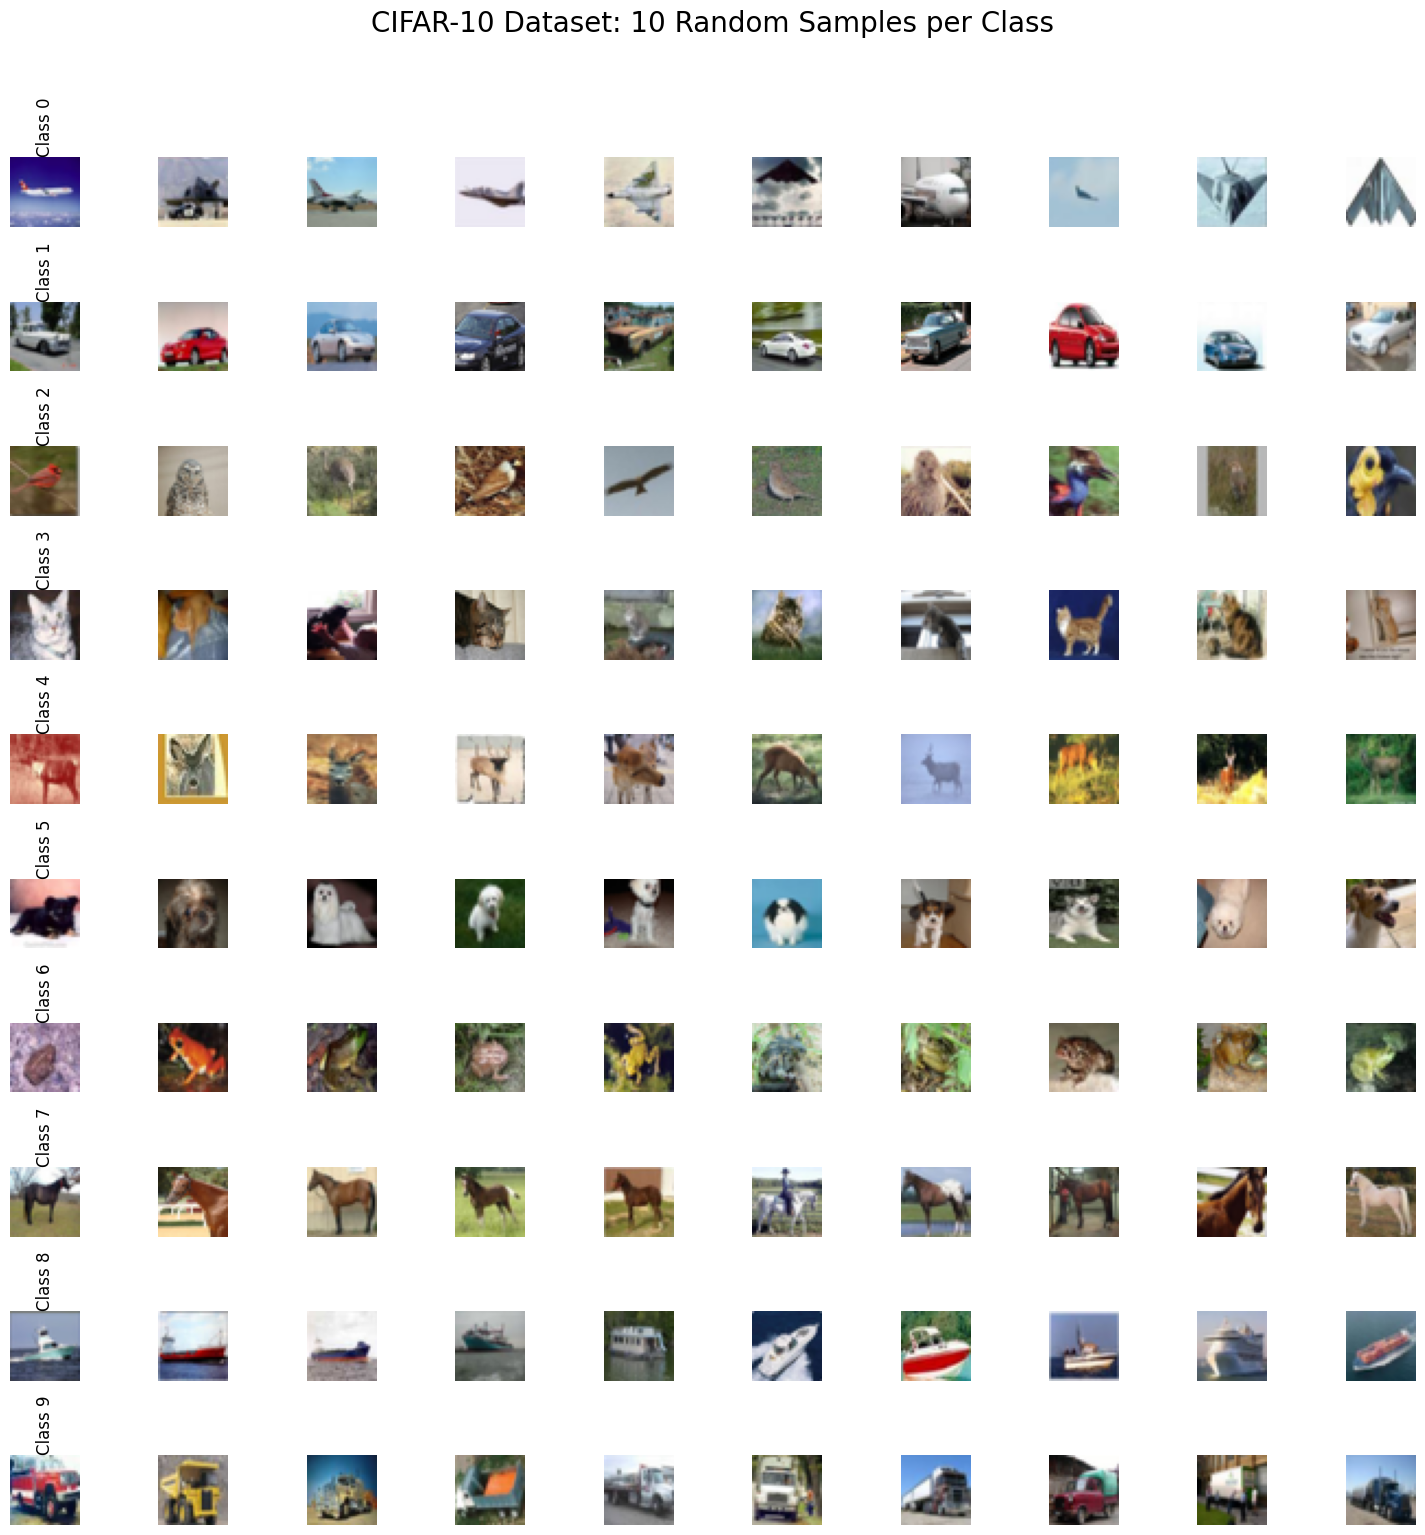

In [6]:
num_classes = 10
samples_per_class = 10
fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(15, 15))

for class_idx in range(num_classes):
    # Get indices of images belonging to the current class
    class_indices = np.where(y_train == class_idx)[0]
    # Randomly select 10 images from this class
    selected_indices = np.random.choice(class_indices, samples_per_class, replace=False)

    for i, img_idx in enumerate(selected_indices):
        axes[class_idx, i].imshow(x_train[img_idx])
        axes[class_idx, i].axis('off')
        if i == 0:
            axes[class_idx, i].set_title(f'Class {class_idx}', rotation=90, ha='center', va='center')

plt.suptitle('CIFAR-10 Dataset: 10 Random Samples per Class', y=1.02, fontsize=20)
plt.tight_layout()
plt.show()

In [7]:
# Normalize images to a range of 0 to 1
X_train = x_train.astype('float32') / 255.0
X_test = x_test.astype('float32') / 255.0

# Convert labels to one-hot encoded form
num_classes = 10
Y_train = to_categorical(y_train, num_classes)
Y_test = to_categorical(y_test, num_classes)

## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer.

Use the input as (32,32,3).

The filter maps can then be flattened to provide features to the classifier.

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [8]:
from keras.backend import clear_session
clear_session()

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [17]:
# Your code here :
model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
epoch = 50
history_model1 = model.fit(X_train, Y_train, epochs=epoch, batch_size=512, validation_data=(X_test, Y_test))

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.6533 - loss: 1.0082 - val_accuracy: 0.6143 - val_loss: 1.1117
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6542 - loss: 1.0058 - val_accuracy: 0.6110 - val_loss: 1.1189
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6586 - loss: 0.9963 - val_accuracy: 0.6105 - val_loss: 1.1122
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6642 - loss: 0.9820 - val_accuracy: 0.6127 - val_loss: 1.1127
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6578 - loss: 0.9908 - val_accuracy: 0.6149 - val_loss: 1.1045
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6632 - loss: 0.9874 - val_accuracy: 0.6043 - val_loss: 1.1183
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6582 - loss: 0.9877 - val_accuracy: 0.6151 - val_loss: 1.1098
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6623 - loss: 0.9798 - val_accuracy: 0.6126 - v

*   Plot the cross entropy loss curve and the accuracy curve

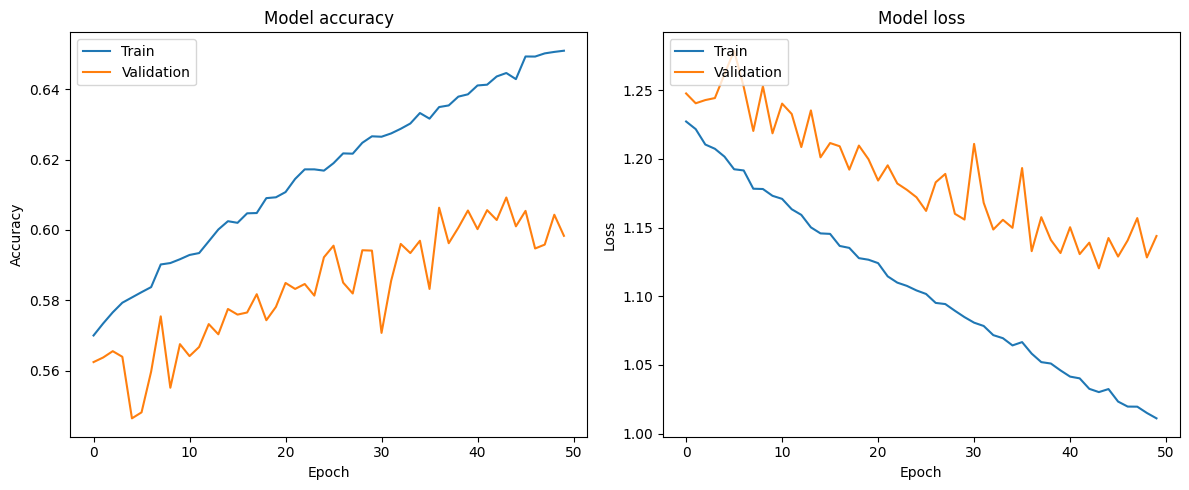

In [18]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3.

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [19]:
from keras.backend import clear_session
clear_session()

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model_deeper = Sequential()
model_deeper.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
model_deeper.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model_deeper.add(MaxPooling2D(pool_size=(2, 2)))
model_deeper.add(Flatten())
model_deeper.add(Dense(128, activation='relu'))
model_deeper.add(Dense(num_classes, activation='softmax'))

model_deeper.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,060,138 (4.04 MB)

 Trainable params: 1,060,138 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [21]:
# Your code here :
model_deeper.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
history_model_deeper = model_deeper.fit(X_train, Y_train, epochs=epoch, batch_size=512, validation_data=(X_test, Y_test))

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - accuracy: 0.1544 - loss: 2.2668 - val_accuracy: 0.2686 - val_loss: 2.1009
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.2665 - loss: 2.0625 - val_accuracy: 0.2801 - val_loss: 2.0314
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.2982 - loss: 1.9801 - val_accuracy: 0.3423 - val_loss: 1.8841
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.3435 - loss: 1.8828 - val_accuracy: 0.3607 - val_loss: 1.8334
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.3608 - loss: 1.8392 - val_accuracy: 0.3780 - val_loss: 1.7840
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.3740 - loss: 1.7899 - val_accuracy: 0.3818 - val_loss: 1.7759
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.3867 - loss: 1.7612 - val_accuracy: 0.4019 - val_loss: 1.7329
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4015 - loss: 1.7218 - val_accuracy: 0.4103 - 

*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.


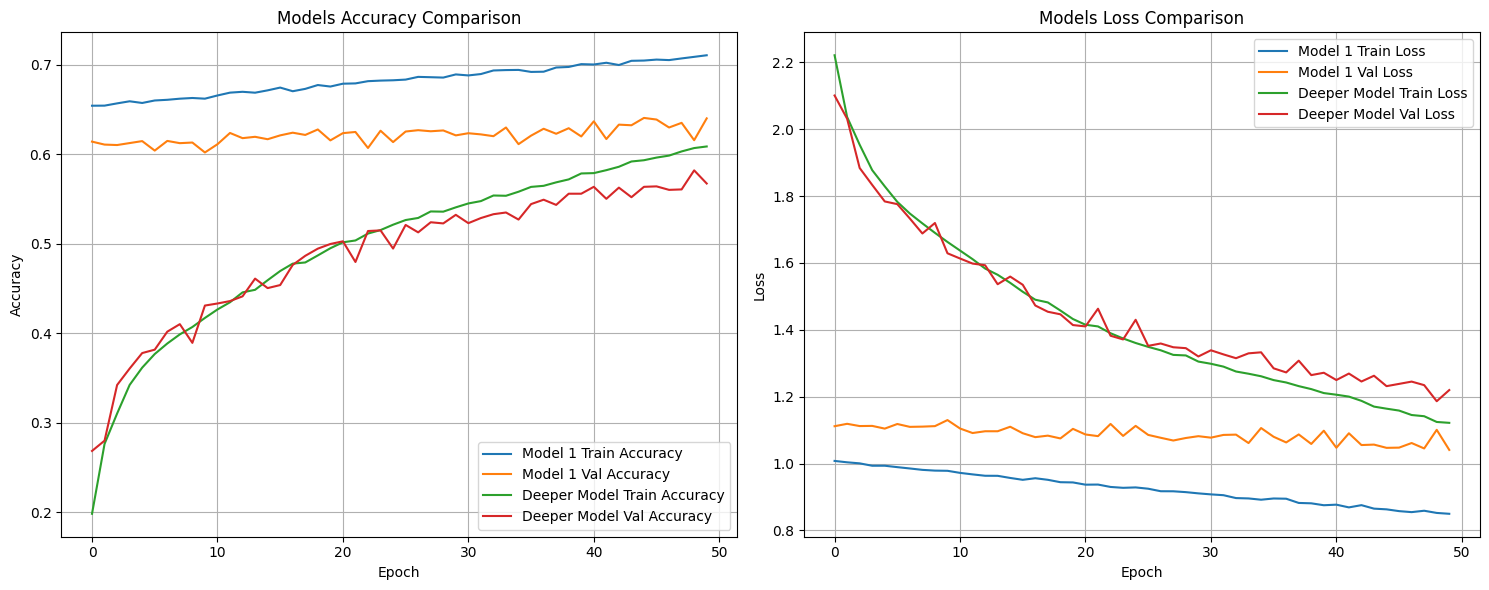

In [22]:
# Your code here :
plt.figure(figsize=(15, 6))

# Plot accuracy for both models
plt.subplot(1, 2, 1)
plt.plot(history_model1.history['accuracy'], label='Model 1 Train Accuracy')
plt.plot(history_model1.history['val_accuracy'], label='Model 1 Val Accuracy')
plt.plot(history_model_deeper.history['accuracy'], label='Deeper Model Train Accuracy')
plt.plot(history_model_deeper.history['val_accuracy'], label='Deeper Model Val Accuracy')
plt.title('Models Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

# Plot loss for both models
plt.subplot(1, 2, 2)
plt.plot(history_model1.history['loss'], label='Model 1 Train Loss')
plt.plot(history_model1.history['val_loss'], label='Model 1 Val Loss')
plt.plot(history_model_deeper.history['loss'], label='Deeper Model Train Loss')
plt.plot(history_model_deeper.history['val_loss'], label='Deeper Model Val Loss')
plt.title('Models Loss Comparison')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Comment on the observation**

*(Double-click or enter to edit)*

Based on the comparison plots, a deeper model generally tends to perform better if it's able to learn more complex features. However, sometimes adding too many layers or inappropriate architectures can lead to diminishing returns or even worse performance due to issues like vanishing/exploding gradients or overfitting if regularization is not applied. Analyze the plots above to determine which model achieves higher validation accuracy and lower validation loss. Observe if the deeper model shows signs of overfitting (e.g., training accuracy much higher than validation accuracy).


*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


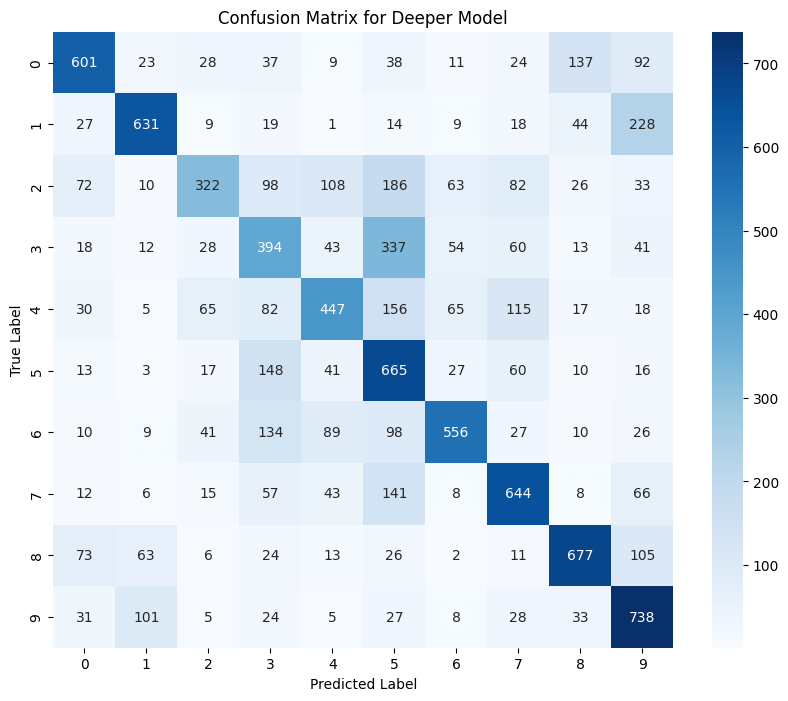

In [23]:
# Your code here :
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict the output for the test split using the deeper model
y_pred_deeper = model_deeper.predict(X_test)
y_pred_classes_deeper = np.argmax(y_pred_deeper, axis=1)

# Convert Y_test from one-hot encoded to class labels
y_true_classes = np.argmax(Y_test, axis=1)

# Plot the confusion matrix
cm_deeper = confusion_matrix(y_true_classes, y_pred_classes_deeper)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_deeper, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Deeper Model')
plt.show()

**Comment here :**

*(Double-click or enter to edit)*

Based on the confusion matrix for the deeper model, we can observe the following:

- **Diagonal values:** These represent the number of correctly classified samples for each class. Higher values on the diagonal indicate better classification performance for that specific class.
- **Off-diagonal values:** These indicate misclassifications. For example, a high value in row `i`, column `j` means that many samples of class `i` were incorrectly predicted as class `j`. This highlights classes that are often confused with each other.

[Add your specific observations about which classes are well-classified and which are confused, and any patterns you notice in the misclassifications.]

*    Print the test accuracy for the trained model.

In [24]:
# Your code here :
test_loss, test_accuracy = model_deeper.evaluate(X_test, Y_test)
print(f"Test Accuracy: {test_accuracy}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5703 - loss: 1.2142
Test Accuracy: 0.5674999952316284


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer.

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling.

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [ ]:
from keras.backend import clear_session
clear_session()

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Resizing

model_vgg = Sequential()

# Input layer to resize images to 64x64
model_vgg.add(Resizing(64, 64, interpolation="bilinear", input_shape=(32, 32, 3)))

# Block 1
model_vgg.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model_vgg.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model_vgg.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
model_vgg.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model_vgg.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model_vgg.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3
model_vgg.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model_vgg.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model_vgg.add(MaxPooling2D(pool_size=(2, 2)))

# Classifier
model_vgg.add(Flatten())
model_vgg.add(Dense(128, activation='relu'))
model_vgg.add(Dense(num_classes, activation='softmax'))

model_vgg.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,978 (12.37 MB)

 Trainable params: 3,243,978 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

In [ ]:
# Your code here :
model_vgg.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
history_model_vgg = model_vgg.fit(X_train, Y_train, epochs=epoch, batch_size=512, validation_data=(X_test, Y_test))

test_loss, test_accuracy = model_vgg.evaluate(X_test, Y_test)
print(f"Test Accuracy: {test_accuracy}")

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 89s 890ms/step - accuracy: 0.1325 - loss: 2.2977 - val_accuracy: 0.1413 - val_loss: 2.2865
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 39s 395ms/step - accuracy: 0.1668 - loss: 2.2766 - val_accuracy: 0.2269 - val_loss: 2.2011
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 411ms/step - accuracy: 0.2205 - loss: 2.1711 - val_accuracy: 0.2645 - val_loss: 2.1003
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 41s 414ms/step - accuracy: 0.2548 - loss: 2.0756 - val_accuracy: 0.2779 - val_loss: 2.0123
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 410ms/step - accuracy: 0.2988 - loss: 1.9798 - val_accuracy: 0.3435 - val_loss: 1.8670
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 413ms/step - accuracy: 0.3272 - loss: 1.9042 - val_accuracy: 0.3442 - val_loss: 1.8170
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 412ms/step - accuracy: 0.3460 - loss: 1.8438 - val_accuracy: 0.3659 - val_loss: 1.7944
Epoch 8/50
78/98 ━━━━━━━━━━━━━━━━━━━━ 7s 389ms/step - accuracy: 0.3553 - loss: 1.8045

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict the output for the test split using the VGG model
y_pred_vgg = model_vgg.predict(X_test)
y_pred_classes_vgg = np.argmax(y_pred_vgg, axis=1)

# Convert Y_test from one-hot encoded to class labels (if not already done)
y_true_classes = np.argmax(Y_test, axis=1)

# Plot the confusion matrix
cm_vgg = confusion_matrix(y_true_classes, y_pred_classes_vgg)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for VGG Model')
plt.show()

# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

1 - Use of activation functions:



_

2 - Key Differences between sigmoid and softmax:



_

3 - Key Differences between categorical crossentropy and binary crossentropy loss:


_
